### EXPLORATORY DATA ANALYSIS AND PREPROCESSING: 
Exploratory Data Analysis (EDA) is the investigative process of visualizing and summarizing a dataset to reveal hidden patterns and relationships, serving as the "compass" that guides your modeling strategy. Data Preprocessing is the subsequent execution phase, where you apply mathematical transformations such as scaling, outlier removal, and class balancing to "sanitize" the data for algorithmic consumption. While EDA tells you what is happening in your data, Preprocessing ensures the data is technically fit to be used by a model, moving it from a raw, biased state into a structured, balanced format ready for training.

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATA

In [2]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

CATEGORIZING TARGET VARIABLE

In [4]:
df['Class'].unique()

array([0, 1])

REVEALING 'CLASS' IMBALANCE, GUIDING EVALUATION STRATEGY AND DECIDING ON DATA SAMPLING USING VALUE_COUNTS METHOD


In [5]:
counts= df['Class'].value_counts()
print(counts)

Class
0    284315
1       492
Name: count, dtype: int64


CHECKING FOR DUPLICATE VALUES
1081 DUPLICATES FOUND

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows_sorted = duplicate_rows.sort_values(by=['Time', 'V1'])
duplicate_rows_sorted.head(12)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


DROPPING DUPLICATE ROWS

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


CHECKING FOR MISSING VALUES: 
NO MISSING VALUES FOUND

In [11]:
missing_values = df.isnull().sum()/len(df)*100
missing_values

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

COUNTPLOT: A Countplot is a bar chart that provides a stark visual representation of the class imbalance within a target variable. By showing the frequency of fraudulent versus legitimate transactions side-by-side, it highlights the extreme rarity of fraud cases, which warns the data scientist that standard accuracy metrics will be misleading. It essentially serves as the "reality check" that dictates whether you need to resample your data or adjust your evaluation metrics to ensure the model actually learns to identify the minority class.

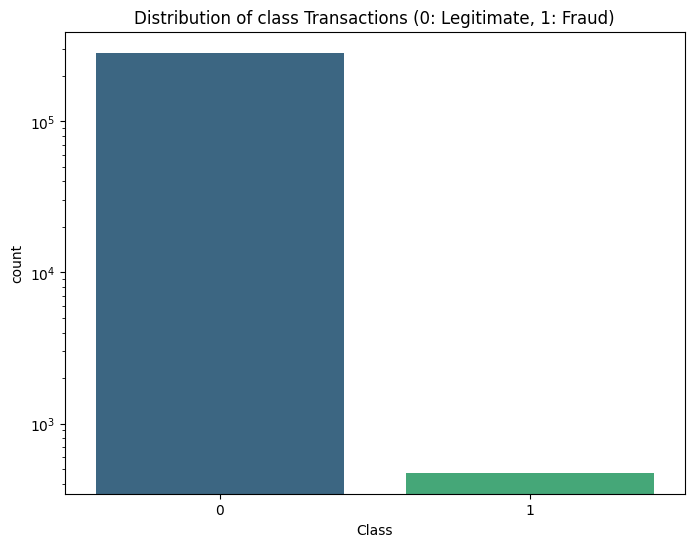

In [12]:
# Countplot for 'Class' distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Distribution of class Transactions (0: Legitimate, 1: Fraud)')
plt.yscale('log') # Use log scale because 1s are so few they might not show up otherwise
plt.show()

THE AMOUNT DISTRIBUTION PLOT:The Amount Distribution plot allows to visually compare the financial scale of legitimate versus fraudulent activity, revealing whether fraudsters favor specific price points or behave differently than the average user. By using side-by-side histograms with density curves,you can identify if fraud is concentrated in small, "stealthy" amounts or large, high-risk charges. This insight is vital for feature engineering, as it helps decide if you should normalize the currency values or create specific "risk buckets" (e.g., "high-value" vs. "low-value") to help your machine learning model distinguish between the two classes.

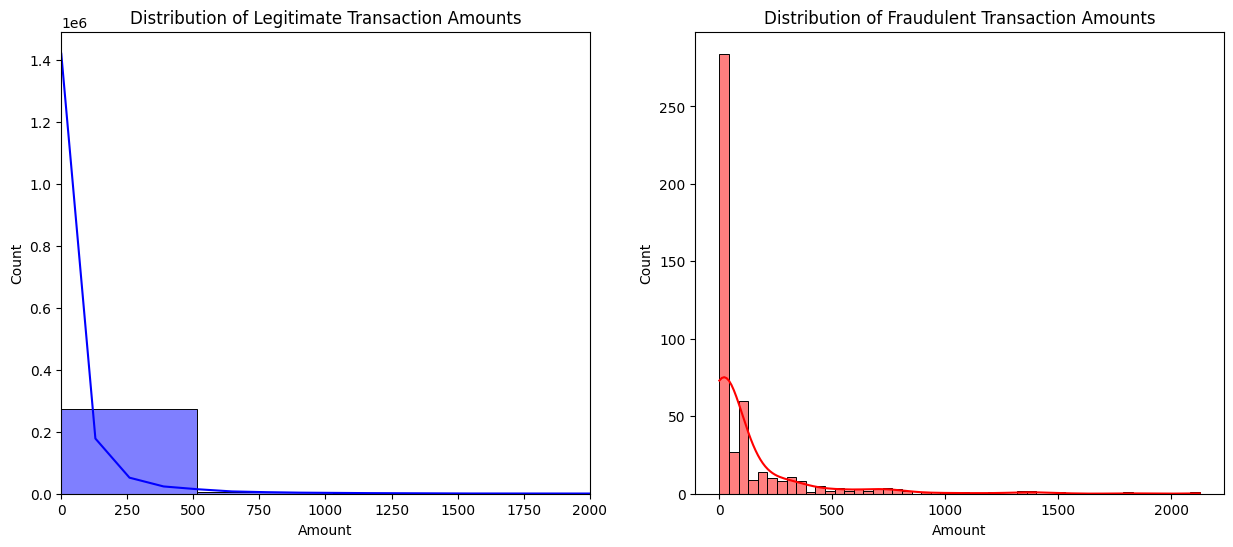

In [13]:
# Amount distribution for both classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Legitimate
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=ax1, kde=True, color='blue')
ax1.set_title('Distribution of Legitimate Transaction Amounts')
ax1.set_xlim([0, 2000]) # Zooming in as most transactions are small

# Plot for Fraud
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=ax2, kde=True, color='red')
ax2.set_title('Distribution of Fraudulent Transaction Amounts')

plt.show()

In [14]:
# The distribution of fraudulent amount shows that lower transactions has the highest amount say $1.00.The histogram plot above
# is evidence and the value_counts() method also confirms it.Even the legitimate transactions is between 0 to $500.
# This means that most fraud attempts is of lower amounts.
print(df[df['Class'] == 1]['Amount'].value_counts().head())

Amount
1.00     105
99.99     27
0.00      25
0.76      17
0.77      10
Name: count, dtype: int64


CORRELATION HEATMAP PLOT:
The Correlation Heatmap serves as a visual compass for your data, condensing the complex relationships between all features into a single, color-coded grid. Its primary purpose is to identify which variables have a strong positive or negative "signal" with the Class variable, signaling that they are high-value predictors for detecting fraud. Simultaneously, it helps to spot multicollinearity, where two features provide redundant information, and validates that the  PCA-transformed features are independent (showing near-zero correlation with one another). Ultimately, it acts as a strategic filter, allowing to ignore "noise" and focus on deep-dive analysis and model training on the most impactful features.

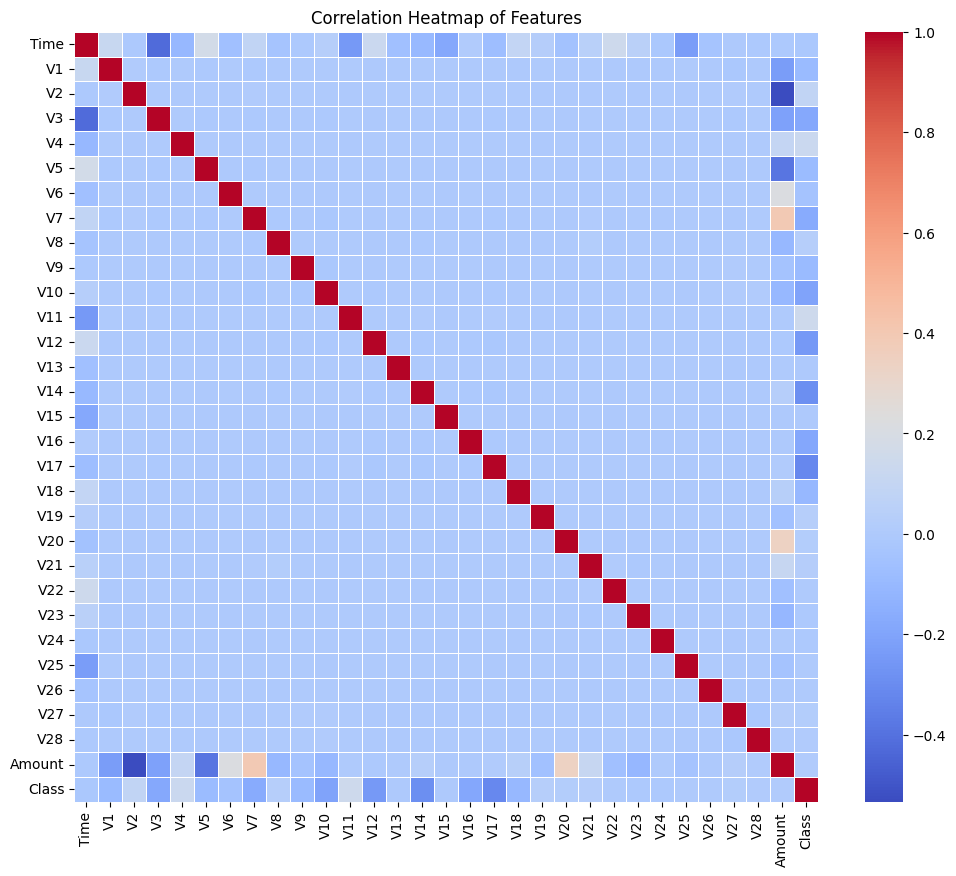

In [15]:
# Correlation matrix
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

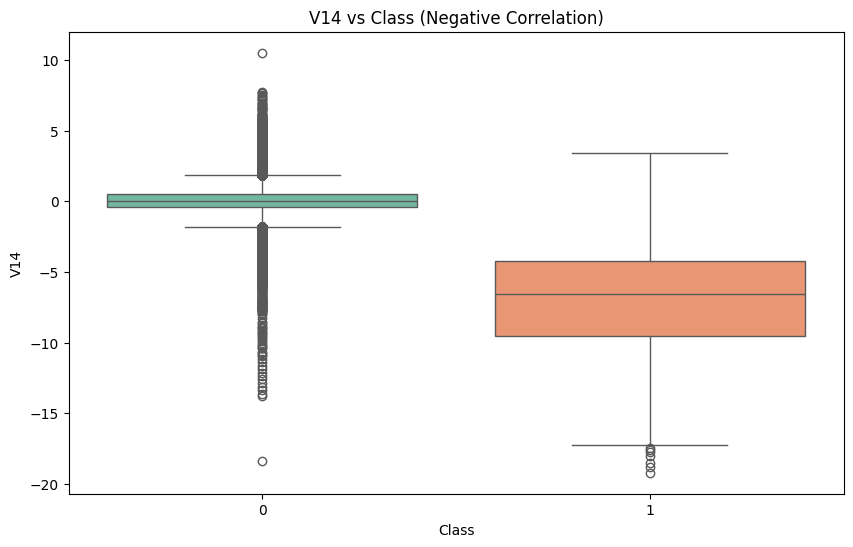

In [16]:
# Boxplots for Feature Comparison
# The heatmap above shows that certain features (like V14,V17 etc.) have a strong negative correlation with fraud, a boxplot 
# is necessary to see the difference in values.

# Comparing V14 distribution for Legitimate (0) vs Fraud (1)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='V14', data=df, hue='Class', palette='Set2', legend=False)
plt.title('V14 vs Class (Negative Correlation)')
plt.show()

IDENTIFYING AND REMOVING OUTLIERS

In [17]:
# From the box plot, you can see outliers. To identify and remove those extreme outliers from your V14 feature, 
# the Interquartile Range (IQR) method will be used. 
# This is a standard practice in data preprocessing to ensure your model doesn't "overfit" to extreme, rare values.
# Calculating the Bounds in the boxplot, the "whiskers" are usually drawn at 1.5*IQR. 
# Anything beyond that is mathematically considered an outlier.Q1(25th Percentile): The bottom of the orange box is Q3 (75th Percentile): 
# The top of your orange box.IQR: The height of the box (Q3 - Q1).

# 1. Isolate the V14 values for Fraud cases
v14_fraud = df['V14'].loc[df['Class'] == 1].values

# 2. Calculate Q1 and Q3
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
v14_iqr = q75 - q25

# 3. Calculate the Lower and Upper Outlier Cutoff
v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off

print(f"V14 Lower Bound: {v14_lower}")
print(f"V14 Upper Bound: {v14_upper}")

# 4. Identify outliers (the dots at the very bottom of the plot)
outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print(f"Total Outliers identified in V14: {len(outliers)}")

V14 Lower Bound: -17.38415366616548
V14 Upper Bound: 3.62654724179084
Total Outliers identified in V14: 7


In [18]:
# Removing outliers only for the fraud class to avoid accidentally deleting legitimate transactions that might just be "unusual" but valid. 
# This is extra safe.

df = df.drop(df[(df['Class'] == 1) & ((df['V14'] > v14_upper) | (df['V14'] < v14_lower))].index)
print(f"New Dataset Shape: {df.shape}")

New Dataset Shape: (283719, 31)


In [20]:
# 1. Isolate the V12 values for Fraud cases
v12_fraud = df['V12'].loc[df['Class'] == 1].values

# 2. Calculate Q1 (25th) and Q3 (75th) percentiles
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

# 3. Calculate the Bounds (using the 1.5 multiplier)
v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off

print(f"V12 Lower Bound: {v12_lower}")
print(f"V12 Upper Bound: {v12_upper}")

# 4. Identify the outliers
outliers_v12 = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print(f"Total Outliers identified in V12: {len(outliers_v12)}")

# 5. Drop them from the main dataframe
df = df.drop(df[(df['Class'] == 1) & ((df['V12'] > v12_upper) | (df['V12'] < v12_lower))].index)
print(f"New Dataset Shape after V12 cleaning: {df.shape}")

V12 Lower Bound: -16.34725875763536
V12 Upper Bound: 5.364830615506912
Total Outliers identified in V12: 2
New Dataset Shape after V12 cleaning: (283710, 31)


In [21]:
# 1. Isolate the V10 values for Fraud cases
v10_fraud = df['V10'].loc[df['Class'] == 1].values

# 2. Calculate Q1 and Q3
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

# 3. Calculate the Bounds
v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off

print(f"V10 Lower Bound: {v10_lower}")
print(f"V10 Upper Bound: {v10_upper}")

# 4. Identify the outliers
outliers_v10 = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print(f"Total Outliers identified in V10: {len(outliers_v10)}")

# 5. Final Drop
df = df.drop(df[(df['Class'] == 1) & ((df['V10'] > v10_upper) | (df['V10'] < v10_lower))].index)
print(f"Final Dataset Shape: {df.shape}")

V10 Lower Bound: -13.545717383084384
V10 Upper Bound: 4.423834967954935
Total Outliers identified in V10: 28
Final Dataset Shape: (283682, 31)


SCALING USING ROBUSTSCALER: Since the previous plots showed the "Amount" column has a very long tail (outliers), RobustScaler is often superior because it uses the median and the interquartile range, making it less sensitive to extreme spending values.

In [22]:
import joblib
from sklearn.preprocessing import RobustScaler

# Initialize
rob_scaler = RobustScaler()

# Scale both columns at once so the scaler "remembers" both
# This creates a single object we can save easily
df[['scaled_amount', 'scaled_time']] = rob_scaler.fit_transform(df[['Amount', 'Time']])

# Drop both columns 
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Save the scaler object to your FRAUD_PROJECT folder
joblib.dump(rob_scaler, '../backend/robust_scaler.pkl')
print("Scaler saved successfully to backend folder!")

Scaler saved successfully to backend folder!


UNDER-SAMPLING

In [23]:
# Under-sampling (Balancing the Classes).The task here is to create a sub-sample. 
# A new dataframe where the number of Fraud and Legitimate cases are equal (50/50).
# This is called Random Under-sampling.Why do this?It forces the model to treat Fraud and Legitimate cases as equally important. 
# It will make the Correlation Heatmap much more colorful and easier to interpret.

# 1. Shuffle the data before creating the sub-sample
df = df.sample(frac=1)

# 2. Separate all fraud cases
fraud_df = df.loc[df['Class'] == 1]

# 3. Randomly select an equal amount of legitimate cases
# We use len(fraud_df) to make sure we have a 50/50 split
legit_df = df.loc[df['Class'] == 0][:len(fraud_df)]

# 4. Concatenate them into a new "Normal Distributed" dataframe
balanced_df = pd.concat([fraud_df, legit_df])

# 5. Shuffle the new balanced dataframe
new_df = balanced_df.sample(frac=1, random_state=42)

print(f"New Balanced Dataset Shape: {new_df.shape}")
print(new_df['Class'].value_counts())

New Balanced Dataset Shape: (858, 31)
Class
0    429
1    429
Name: count, dtype: int64


The "Hybrid" Way (SMOTE on Under-sampled data)
To keep the "Normal Distribution" created but want a slightly larger dataset to train on without using the full 284,000 rows, you can apply SMOTE to the new_df.

USING SMOTE AFTER UNDER-SAMPLING

In [24]:
#pip install imbalanced-learn, to use SMOTE
from imblearn.over_sampling import SMOTE

# Use the 'new_df' you just created in your code above
X_sub = new_df.drop('Class', axis=1)
y_sub = new_df['Class']

# SMOTE will now create synthetic cases based ONLY on your sub-sample
# Let's say you want to double your data size
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_hybrid, y_hybrid = sm.fit_resample(X_sub, y_sub)

print(f"Hybrid Dataset Shape: {X_hybrid.shape}")

Hybrid Dataset Shape: (858, 30)


In [25]:
# Combine features and target into one DataFrame for EDA
new_balanced_df = pd.concat([pd.DataFrame(X_hybrid), pd.Series(y_hybrid, name='Class')], axis=1)

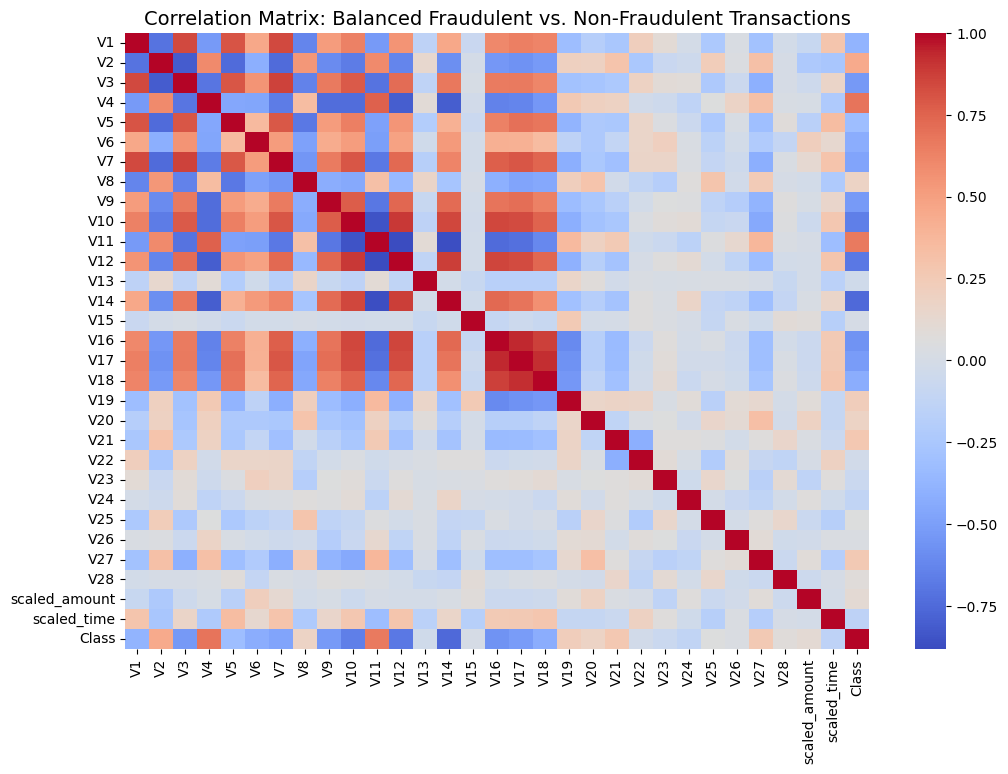

In [26]:
plt.figure(figsize=(12,8))
corr = new_balanced_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot_kws={'size':20})
plt.title('Correlation Matrix: Balanced Fraudulent vs. Non-Fraudulent Transactions', fontsize=14)
plt.show()

The correlation heatmap of the balanced dataset reveals significant linear relationships between the anonymized features and the target Class that were previously hidden by the class imbalance. Highly saturated red cells (positive correlation) and deep blue cells (negative correlation) in the bottom row indicate that features such as V4, V11, and V19 are positively correlated with fraud, meaning their values tend to increase during fraudulent transactions. Conversely, features like V10, V12, V14, and V17 show strong negative correlations, suggesting they decrease when fraud occurs. By balancing the classes, the model can now clearly identify these predictive patterns, as the multicollinearity and distinct "blocks" of correlated features (like the V16–V18 cluster) are no longer drowned out by the overwhelming majority of legitimate transactions. This provides a high-fidelity "compass" for your upcoming modeling phase, highlighting which variables will be most influential in detecting fraud.

CREATING BOXPLOTS:Creating boxplots is the logical next step to physically inspect the distribution and presence of outliers within those highly correlated features. While the heatmap identifies which variables like V10, V12, V14, or V17 have a strong relationship with fraud, it does not reveal the specific range of values or the "noise" in the data. Boxplots allow you to visualize the quartiles and identify extreme outliers that could potentially mislead your machine learning model during the training phase. This is especially critical for your "model-focused" study, as it provides the empirical justification for whether you need to perform further data cleaning or outlier removal to improve the predictive accuracy of your fraud detection pipeline.

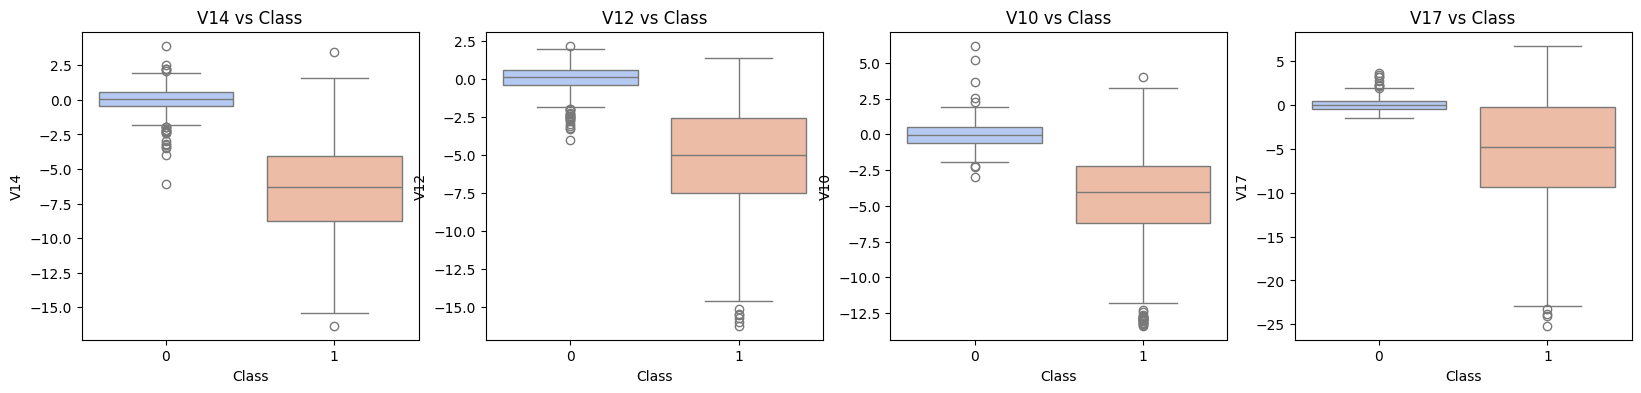

In [27]:
# Features with high negative correlation from your heatmap
neg_corr_features = ['V14', 'V12', 'V10', 'V17']

f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Creating boxplots with the updated syntax
for i, feature in enumerate(neg_corr_features):
    sns.boxplot(
        x="Class", 
        y=feature, 
        data=new_balanced_df, 
        hue="Class",      # Assign hue to x variable
        palette='coolwarm', 
        legend=False,     # Remove redundant legend
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} vs Class')

plt.show()

The Class Comparison Boxplots confirm that the selected features possess high discriminatory power, as evidenced by the clear physical separation between the legitimate and fraudulent distributions. For features like V14 and V12, the fraudulent class exhibits significantly lower medians than the legitimate class, providing the machine learning algorithm with distinct "decision boundaries" to exploit. The minimal overlap between the interquartile ranges suggests that these variables are robust indicators of fraud, though the presence of remaining outliers in the fraud class highlights the extreme variability inherent in criminal transaction patterns. By visualizing these features side-by-side, it becomes evident that lower values in V14, V12, V10, and V17 serve as the primary "decision drivers" for differentiating transaction types in your model.

SPLITTING DATA INTO TRAINING AND TESTING

In [28]:
# X is everything except the 'Class' column from your balanced data
X = new_balanced_df.drop('Class', axis=1)

# y is just the 'Class' column from your balanced data
y = new_balanced_df['Class']

In [29]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,1.286640,1.475574,-1.631309,1.723992,1.245609,-1.474893,0.742967,-0.493993,0.716269,-1.950379,...,-0.381866,-0.698863,-0.270642,-0.472422,0.935834,-0.305352,0.019315,0.087709,-0.292032,-0.736784
1,-1.422297,1.810593,-0.443548,0.108016,-0.777323,-1.117592,-0.132390,1.000558,-1.195239,-0.510648,...,0.360250,0.511985,0.050109,0.578338,-0.100142,0.306083,-0.779391,-0.189838,-0.090391,-0.095258
2,-2.756007,0.683821,-1.390169,1.501887,-1.165614,-0.131207,-1.478741,-0.246922,-0.100523,-2.301110,...,0.320474,0.611027,0.174864,-0.502151,-0.174713,1.179242,-1.166315,0.821215,1.105549,-0.277124
3,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,-12.888158,...,2.571970,0.206809,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,-0.305938,-0.510685
4,-0.395582,-0.751792,-1.984666,-0.203459,1.903967,-1.430289,-0.076548,-0.992260,0.756307,0.217630,...,1.377515,2.151787,0.189225,0.772943,-0.872443,-0.200612,0.356856,0.032113,-0.296343,0.647813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,-1.426623,4.141986,-9.804103,6.666273,-4.749527,-2.073129,-10.089931,2.791345,-3.249516,-11.420451,...,1.865679,0.407809,0.605809,-0.769348,-1.746337,0.502040,1.977258,0.711607,-0.292032,-0.864429
854,-2.064240,2.629739,-0.748406,0.694992,0.418178,1.392520,-1.697801,-6.333065,1.724184,-0.887242,...,6.215514,-1.276909,0.459861,-1.051685,0.209178,-0.319859,0.015434,-0.050117,-0.194688,0.732213
855,-21.885434,12.930505,-24.098872,6.203314,-16.466099,-4.459842,-16.519836,14.535565,-3.897022,-8.650758,...,1.762232,-1.579055,-0.951043,0.134565,1.507110,-0.222671,1.527655,0.453699,1.084550,-0.679131
856,-0.903448,-0.821920,1.191299,-4.192177,-1.056723,-1.485427,0.422021,-0.076161,1.000333,-1.587837,...,-0.220884,-0.181996,0.140582,0.325779,0.145120,-1.087335,0.377589,0.215691,1.347935,-0.255184


In [30]:
y

0      0
1      0
2      1
3      1
4      1
      ..
853    1
854    1
855    1
856    0
857    1
Name: Class, Length: 858, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((686, 30), (172, 30), (686,), (172,))

In [33]:

# Using a representative sample to keep file size small
from sklearn.model_selection import train_test_split

# Use full scaled dataset
X_full = df.drop('Class', axis=1)
y_full = df['Class']


# Keep ALL fraud cases 10,000 legitimate cases
fraud_data = df[df['Class'] == 1]
legit_data = df[df['Class'] == 0].sample(n=10000, random_state=42)

# Combine them
sample_df = pd.concat([fraud_data, legit_data]).sample(frac=1, random_state=42)

X_sample = sample_df.drop('Class', axis=1)
y_sample = sample_df['Class']

print(f"Sample dataset size: {sample_df.shape}")
print(f"Class distribution:\n{y_sample.value_counts()}")

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print(f"\nBefore SMOTE:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")

Sample dataset size: (10429, 31)
Class distribution:
Class
0    10000
1      429
Name: count, dtype: int64

Before SMOTE:
X_train shape: (8343, 30)
X_test shape:  (2086, 30)
Training class distribution:
Class
0    8000
1     343
Name: count, dtype: int64


In [34]:
# Apply SMOTE only on training data
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy='auto', random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"After SMOTE:")
print(f"X_train shape: {X_train_sm.shape}")
print(f"Training class distribution:\n{pd.Series(y_train_sm).value_counts()}")
print(f"\nTest set untouched:")
print(f"X_test shape: {X_test.shape}")
print(f"Test class distribution:\n{y_test.value_counts()}")

After SMOTE:
X_train shape: (16000, 30)
Training class distribution:
Class
0    8000
1    8000
Name: count, dtype: int64

Test set untouched:
X_test shape: (2086, 30)
Test class distribution:
Class
0    2000
1      86
Name: count, dtype: int64


In [36]:
import joblib

# Save new larger datasets for Paul
joblib.dump(X_train_sm, '../notebook/X_train.pkl')
joblib.dump(X_test, '../notebook/X_test.pkl')
joblib.dump(y_train_sm, '../notebook/y_train.pkl')
joblib.dump(y_test, '../notebook/y_test.pkl')

print(f"✅ X_train saved: {X_train_sm.shape}")
print(f"✅ X_test saved:  {X_test.shape}")
print(f"✅ y_train saved: {y_train_sm.shape}")
print(f"✅ y_test saved:  {y_test.shape}")
print("✅ All datasets saved successfully for Paul!")

✅ X_train saved: (16000, 30)
✅ X_test saved:  (2086, 30)
✅ y_train saved: (16000,)
✅ y_test saved:  (2086,)
✅ All datasets saved successfully for Paul!
